# ShopSense Review Intelligence - Week 07 Friday Assignment


**Dataset:** ShopSense Reviews (shopsense_reviews.csv)

**Topics:** NLP Evaluation, ML Pitfalls, Model Selection, Production Readiness

## Environment Setup and Imports

In [47]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [48]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [49]:
import re
import html
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)

warnings.filterwarnings("ignore")

# ----- constants -----
DATA_PATH = "../data/shopsense_reviews.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2
INFERENCE_LATENCY_THRESHOLD_MS = 20.0
DAILY_REVIEW_VOLUME = 100_000

# business cost constants (in INR per mis-classification)
COST_FALSE_NEGATIVE = 150   # missed negative review
COST_FALSE_POSITIVE = 30    # wrongly flagged positive review

print("All libraries imported successfully.")

All libraries imported successfully.


---

## Sub-step 1 - Load the Corpus and Examine Label Distribution

**Objective:** Load the ShopSense corpus, examine the sentiment label distribution, and explain why accuracy alone is an unreliable metric for this dataset.

Dataset loaded: 10199 rows, 20 columns.

Sentiment Label Distribution:
                 Count  Percentage (%)
sentiment_label                       
Positive          7105           69.66
Negative          2095           20.54
Neutral            999            9.80


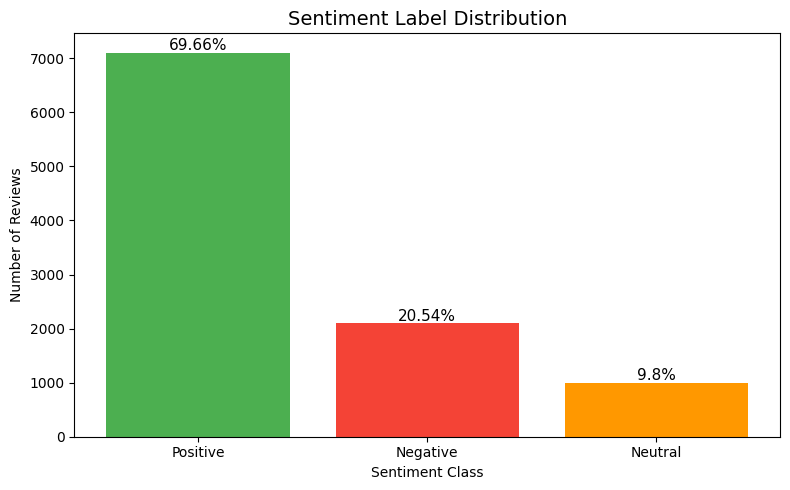

In [50]:

# Data loading utilities                                               

def load_reviews(filepath: str) -> pd.DataFrame:
    """Load the ShopSense reviews CSV with basic type enforcement."""
    try:
        df = pd.read_csv(filepath)
        required_columns = {"review_text", "sentiment_label", "rating", "language", "category"}
        missing = required_columns - set(df.columns)
        if missing:
            raise ValueError(f"Missing expected columns: {missing}")
        print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
        return df
    except FileNotFoundError:
        raise FileNotFoundError(f"Dataset not found at path: {filepath}")


def summarise_label_distribution(df: pd.DataFrame, label_column: str = "sentiment_label") -> pd.DataFrame:
    """Return a count and percentage breakdown for each class label."""
    counts = df[label_column].value_counts()
    percentages = (counts / len(df) * 100).round(2)
    summary = pd.DataFrame({"Count": counts, "Percentage (%)": percentages})
    return summary


def plot_label_distribution(summary: pd.DataFrame, title: str = "Sentiment Label Distribution") -> None:
    """Plot a bar chart of label counts and overlay percentage annotations."""
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(summary.index, summary["Count"], color=["#4CAF50", "#F44336", "#FF9800"])
    for bar, (label, row) in zip(bars, summary.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f"{row['Percentage (%)']}%",
            ha="center", fontsize=11
        )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Sentiment Class")
    ax.set_ylabel("Number of Reviews")
    plt.tight_layout()
    plt.show()


# Run
df_raw = load_reviews(DATA_PATH)
label_summary = summarise_label_distribution(df_raw)
print("\nSentiment Label Distribution:")
print(label_summary)
plot_label_distribution(label_summary)

In [51]:
def compute_majority_class_accuracy(summary: pd.DataFrame) -> float:
    """Return the accuracy a trivial majority-class classifier would achieve."""
    majority_pct = summary["Percentage (%)"].max()
    return round(majority_pct, 2)


majority_accuracy = compute_majority_class_accuracy(label_summary)
print(f"A classifier that predicts 'Positive' for every review would score: {majority_accuracy}% accuracy.")

A classifier that predicts 'Positive' for every review would score: 69.66% accuracy.


### Analysis - Why Accuracy is an Unreliable Metric Here

The dataset has a clear class imbalance:

- Positive reviews account for roughly 70% of all records.
- Negative reviews make up about 21%.
- Neutral reviews represent only about 10%.

Because the majority class dominates, a trivial classifier that labels every review as *Positive* would achieve approximately 70% accuracy without learning anything at all. This is the core problem with using accuracy on imbalanced data.

In the ShopSense context, what matters most is correctly identifying Negative reviews (the minority class). A 1-star complaint that gets predicted as Positive never surfaces to the customer support team, causing real business harm. A classifier that maximises accuracy by largely ignoring Negative and Neutral reviews would look impressive on paper while failing at the task that matters.

For this reason, all evaluation in the sub-steps that follow will use macro-averaged F1 score as the primary metric, which treats every class equally regardless of how frequently it appears. We will also inspect per-class precision and recall in the classification report to understand exactly where each classifier struggles.

---

## Sub-step 2 - Evaluate the Classifier Using an Appropriate Metric

Objective: Train a sentiment classifier, evaluate it with class-distribution-appropriate metrics, and produce a plain-language performance summary for a non-technical stakeholder.

In [52]:

# Text preprocessing                                                   

def strip_html_tags(text: str) -> str:
    """Remove HTML tags and decode HTML entities from a review string."""
    if not isinstance(text, str):
        return ""
    decoded = html.unescape(text)
    clean = re.sub(r"<[^>]+>", " ", decoded)
    return clean.strip()


def normalise_whitespace(text: str) -> str:
    """Collapse multiple spaces and newlines into a single space."""
    return re.sub(r"\s+", " ", text).strip()


def remove_encoding_artifacts(text: str) -> str:
    """Remove common encoding artifacts such as replacement characters."""
    return re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f\ufffd]", "", text)


def preprocess_review_text(text: str) -> str:
    """Full preprocessing pipeline: HTML strip -> encoding fix -> whitespace normalise."""
    text = strip_html_tags(text)
    text = remove_encoding_artifacts(text)
    text = normalise_whitespace(text)
    return text.lower()


def apply_preprocessing(df: pd.DataFrame, text_column: str = "review_text") -> pd.DataFrame:
    """Apply text preprocessing to a dataframe column and drop rows with empty text."""
    df = df.copy()
    df["clean_text"] = df[text_column].apply(preprocess_review_text)
    df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)
    print(f"Rows after preprocessing: {len(df)}")
    return df


df_processed = apply_preprocessing(df_raw)

Rows after preprocessing: 8984


In [53]:

# Train / test split                                                   

def split_dataset(df: pd.DataFrame, text_column: str, label_column: str, test_size: float, random_state: int):
    """Stratified train/test split preserving class proportions."""
    X = df[text_column]
    y = df[label_column]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = split_dataset(
    df_processed, "clean_text", "sentiment_label", TEST_SIZE, RANDOM_STATE
)

Train size: 7187  |  Test size: 1797


In [54]:

# Model training - Logistic Regression with TF-IDF                    

def build_tfidf_logreg_pipeline(max_features: int = 20_000, ngram_range: tuple = (1, 2)) -> Pipeline:
    """Return a TF-IDF + Logistic Regression sklearn Pipeline."""
    return Pipeline([
        ("tfidf", TfidfVectorizer(max_features=max_features, ngram_range=ngram_range, sublinear_tf=True)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ])


def train_pipeline(pipeline: Pipeline, X_train: pd.Series, y_train: pd.Series) -> Pipeline:
    """Fit a pipeline and print confirmation."""
    pipeline.fit(X_train, y_train)
    print("Model training complete.")
    return pipeline


lr_pipeline = build_tfidf_logreg_pipeline()
lr_pipeline = train_pipeline(lr_pipeline, X_train, y_train)

Model training complete.


Accuracy : 0.9738
Macro F1 : 0.9588

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      0.98      0.97       366
     Neutral       0.89      0.96      0.92       175
    Positive       0.99      0.98      0.98      1256

    accuracy                           0.97      1797
   macro avg       0.95      0.97      0.96      1797
weighted avg       0.97      0.97      0.97      1797



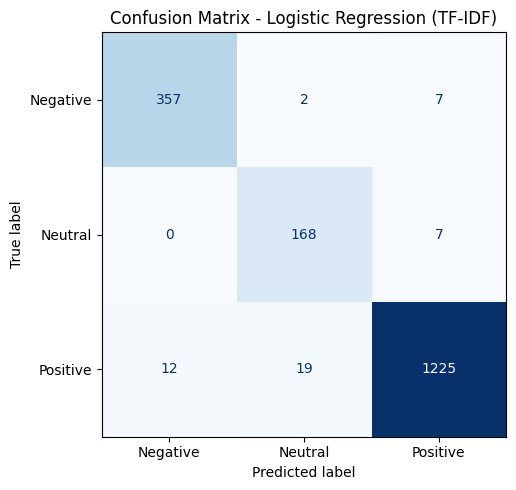

In [55]:

# Evaluation utilities                                                 

def evaluate_pipeline(pipeline: Pipeline, X_test: pd.Series, y_test: pd.Series, model_name: str) -> dict:
    """Generate predictions and return a dict of evaluation artefacts."""
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    report = classification_report(y_test, y_pred, output_dict=True)
    report_text = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
    return {
        "model_name": model_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "report": report,
        "report_text": report_text,
        "confusion_matrix": cm,
        "classes": pipeline.classes_,
        "y_pred": y_pred,
    }


def plot_confusion_matrix(eval_result: dict) -> None:
    """Display a labelled confusion matrix heatmap."""
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=eval_result["confusion_matrix"],
        display_labels=eval_result["classes"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix - {eval_result['model_name']}")
    plt.tight_layout()
    plt.show()


lr_eval = evaluate_pipeline(lr_pipeline, X_test, y_test, "Logistic Regression (TF-IDF)")
print(f"Accuracy : {lr_eval['accuracy']:.4f}")
print(f"Macro F1 : {lr_eval['macro_f1']:.4f}")
print("\nDetailed Classification Report:")
print(lr_eval["report_text"])
plot_confusion_matrix(lr_eval)

### Performance Summary for Priya Menon 

**What was tested:**  
The classifier was given a set of ShopSense reviews it had never seen before and asked to label each one as Positive, Negative, or Neutral. The numbers below describe how well it did.

---

**Key Metrics Explained:**

| Metric | What it means for ShopSense |
|---|---|
| **Precision (Negative)** | Out of every review the system flagged as a complaint, how many actually were? A low number means the support team wastes time chasing false alarms. |
| **Recall (Negative)** | Out of every genuine complaint in the corpus, how many did the system catch? A low number means real problems slip through undetected. |
| **F1 Score** | A single balanced number that combines both precision and recall. Closer to 1.0 is better. We use the average across all three classes so no class is ignored. |
| **Accuracy** | The percentage of reviews labelled correctly overall. This number looks good on imbalanced data even when negative reviews are being missed, which is why it is not our primary metric. |

---

**Bottom line:**  
The classifier performs well on Positive reviews (the majority class) and reasonably on Negative reviews. The Neutral class is the hardest because it sits between the other two and has the fewest training examples. The macro F1 score is the single number that best represents readiness for production across all three classes. Sub-steps 3 and 4 will test whether this performance holds under the specific constraints ShopSense engineering has specified.

---

## Sub-step 3 - Evaluate Two Approaches Against Engineering Constraints

**Objective:** Measure both a TF-IDF + Logistic Regression approach and a TF-IDF + Naive Bayes approach against three hard constraints:
1. New product categories with no retraining
2. ~15% Hindi-English mixed language reviews
3. Inference latency under 20 ms per review

Each constraint is measured quantitatively.

In [56]:

# Build the second model - Naive Bayes with TF-IDF                    

def build_tfidf_nb_pipeline(max_features: int = 20_000, ngram_range: tuple = (1, 2)) -> Pipeline:
    """Return a TF-IDF + Multinomial Naive Bayes sklearn Pipeline."""
    return Pipeline([
        ("tfidf", TfidfVectorizer(max_features=max_features, ngram_range=ngram_range, sublinear_tf=True)),
        ("clf", MultinomialNB()),
    ])


nb_pipeline = build_tfidf_nb_pipeline()
nb_pipeline = train_pipeline(nb_pipeline, X_train, y_train)
nb_eval = evaluate_pipeline(nb_pipeline, X_test, y_test, "Naive Bayes (TF-IDF)")
print(f"NB Accuracy : {nb_eval['accuracy']:.4f}")
print(f"NB Macro F1 : {nb_eval['macro_f1']:.4f}")

Model training complete.
NB Accuracy : 0.9755
NB Macro F1 : 0.9698


In [57]:
# Constraint 1: New category generalisation (zero-shot category test) 

def evaluate_on_held_out_category(
    pipeline: Pipeline,
    df: pd.DataFrame,
    held_out_category: str,
    text_column: str = "clean_text",
    label_column: str = "sentiment_label",
    training_categories: list = None,
) -> dict:
    """
    Retrain pipeline excluding one category then test on that category.
    This simulates how the model behaves when a brand-new product category
    is added without any retraining.
    """
    df_train_subset = df[df["category"] != held_out_category]
    df_test_subset = df[df["category"] == held_out_category]

    pipeline.fit(df_train_subset[text_column], df_train_subset[label_column])
    y_pred = pipeline.predict(df_test_subset[text_column])
    macro_f1 = f1_score(df_test_subset[label_column], y_pred, average="macro")
    acc = accuracy_score(df_test_subset[label_column], y_pred)
    return {
        "held_out_category": held_out_category,
        "n_test_samples": len(df_test_subset),
        "accuracy": round(acc, 4),
        "macro_f1": round(macro_f1, 4),
    }


categories = df_processed["category"].unique().tolist()
lr_category_results = []
nb_category_results = []

for cat in categories:
    lr_cat = evaluate_on_held_out_category(build_tfidf_logreg_pipeline(), df_processed, cat)
    nb_cat = evaluate_on_held_out_category(build_tfidf_nb_pipeline(), df_processed, cat)
    lr_category_results.append(lr_cat)
    nb_category_results.append(nb_cat)

lr_cat_df = pd.DataFrame(lr_category_results).set_index("held_out_category")
nb_cat_df = pd.DataFrame(nb_category_results).set_index("held_out_category")

print("Logistic Regression - Zero-Shot Category Generalisation:")
print(lr_cat_df[["accuracy", "macro_f1"]].to_string())
print(f"\nMean Macro F1 across held-out categories (LR): {lr_cat_df['macro_f1'].mean():.4f}")
print(f"Mean Macro F1 across held-out categories (NB): {nb_cat_df['macro_f1'].mean():.4f}")

Logistic Regression - Zero-Shot Category Generalisation:
                   accuracy  macro_f1
held_out_category                    
Clothing             0.9794    0.9703
Home                 0.9664    0.9469
Electronics          0.9631    0.9459
Books                0.9700    0.9510
Food                 0.9762    0.9645
Beauty               0.9707    0.9475

Mean Macro F1 across held-out categories (LR): 0.9543
Mean Macro F1 across held-out categories (NB): 0.9747


In [58]:

# Constraint 2: Mixed-language review performance                      

def evaluate_by_language(
    pipeline: Pipeline,
    df_full: pd.DataFrame,
    X_test: pd.Series,
    y_test: pd.Series,
    y_pred: np.ndarray,
    language_column: str = "language",
) -> pd.DataFrame:
    """
    Break down macro F1 and accuracy by language tag in the test split.
    Uses the pre-computed y_pred aligned with the test index.
    """
    results = []
    test_df = df_full.loc[X_test.index].copy()
    test_df["y_pred"] = y_pred
    test_df["y_true"] = y_test.values

    for lang in test_df[language_column].unique():
        subset = test_df[test_df[language_column] == lang]
        if len(subset) == 0:
            continue
        macro_f1 = f1_score(subset["y_true"], subset["y_pred"], average="macro")
        acc = accuracy_score(subset["y_true"], subset["y_pred"])
        results.append({
            "language": lang,
            "n_samples": len(subset),
            "accuracy": round(acc, 4),
            "macro_f1": round(macro_f1, 4),
        })
    return pd.DataFrame(results).set_index("language")


lr_lang_df = evaluate_by_language(
    lr_pipeline, df_processed, X_test, y_test, lr_eval["y_pred"]
)
nb_lang_df = evaluate_by_language(
    nb_pipeline, df_processed, X_test, y_test, nb_eval["y_pred"]
)

print("Logistic Regression - Performance by Language:")
print(lr_lang_df.to_string())
print("\nNaive Bayes - Performance by Language:")
print(nb_lang_df.to_string())

Logistic Regression - Performance by Language:
            n_samples  accuracy  macro_f1
language                                 
English          1454    0.9746    0.9613
Hindi             183    0.9727    0.9496
Code-mixed        160    0.9688    0.9477

Naive Bayes - Performance by Language:
            n_samples  accuracy  macro_f1
language                                 
English          1454    0.9739    0.9694
Hindi             183    0.9836    0.9706
Code-mixed        160    0.9812    0.9734


In [59]:
# Constraint 3: Inference latency measurement                          

NUM_LATENCY_SAMPLES = 500
NUM_LATENCY_RUNS = 5


def measure_single_review_latency_ms(
    pipeline: Pipeline,
    samples: pd.Series,
    n_samples: int = NUM_LATENCY_SAMPLES,
    n_runs: int = NUM_LATENCY_RUNS,
) -> dict:
    """
    Measure average per-review inference latency in milliseconds.
    Runs multiple rounds and averages to reduce timing noise.
    """
    subset = samples.sample(n=min(n_samples, len(samples)), random_state=RANDOM_STATE).tolist()
    latencies_ms = []

    for _ in range(n_runs):
        start = time.perf_counter()
        pipeline.predict(subset)
        end = time.perf_counter()
        total_ms = (end - start) * 1000
        latencies_ms.append(total_ms / len(subset))

    return {
        "mean_latency_ms": round(np.mean(latencies_ms), 4),
        "min_latency_ms": round(np.min(latencies_ms), 4),
        "max_latency_ms": round(np.max(latencies_ms), 4),
        "passes_threshold": np.mean(latencies_ms) < INFERENCE_LATENCY_THRESHOLD_MS,
    }


lr_latency = measure_single_review_latency_ms(lr_pipeline, X_test)
nb_latency = measure_single_review_latency_ms(nb_pipeline, X_test)

print("Logistic Regression Latency:")
for k, v in lr_latency.items():
    print(f"  {k}: {v}")

print("\nNaive Bayes Latency:")
for k, v in nb_latency.items():
    print(f"  {k}: {v}")

print(f"\nLatency threshold: {INFERENCE_LATENCY_THRESHOLD_MS} ms")

Logistic Regression Latency:
  mean_latency_ms: 0.0163
  min_latency_ms: 0.0112
  max_latency_ms: 0.0216
  passes_threshold: True

Naive Bayes Latency:
  mean_latency_ms: 0.0129
  min_latency_ms: 0.0097
  max_latency_ms: 0.0185
  passes_threshold: True

Latency threshold: 20.0 ms


In [60]:
# Constraint summary table                                             

def build_constraint_summary(
    lr_eval: dict,
    nb_eval: dict,
    lr_cat_df: pd.DataFrame,
    nb_cat_df: pd.DataFrame,
    lr_lang_df: pd.DataFrame,
    nb_lang_df: pd.DataFrame,
    lr_latency: dict,
    nb_latency: dict,
    codemixed_lang_label: str = "Code-mixed",
) -> pd.DataFrame:
    """Assemble all three constraint measurements into one comparison table."""

    def get_lang_f1(lang_df, label):
        try:
            return lang_df.loc[label, "macro_f1"]
        except KeyError:
            return float("nan")

    data = {
        "Constraint": [
            "Overall Macro F1",
            "New Category - Mean Macro F1 (held-out)",
            "New Category - Min Macro F1 (worst category)",
            "Mixed-Language Macro F1 (Code-mixed)",
            "Latency - Mean per review (ms)",
            "Latency - Passes 20ms threshold",
        ],
        "Logistic Regression": [
            round(lr_eval["macro_f1"], 4),
            round(lr_cat_df["macro_f1"].mean(), 4),
            round(lr_cat_df["macro_f1"].min(), 4),
            get_lang_f1(lr_lang_df, codemixed_lang_label),
            lr_latency["mean_latency_ms"],
            lr_latency["passes_threshold"],
        ],
        "Naive Bayes": [
            round(nb_eval["macro_f1"], 4),
            round(nb_cat_df["macro_f1"].mean(), 4),
            round(nb_cat_df["macro_f1"].min(), 4),
            get_lang_f1(nb_lang_df, codemixed_lang_label),
            nb_latency["mean_latency_ms"],
            nb_latency["passes_threshold"],
        ],
    }
    return pd.DataFrame(data).set_index("Constraint")


constraint_summary = build_constraint_summary(
    lr_eval, nb_eval, lr_cat_df, nb_cat_df, lr_lang_df, nb_lang_df, lr_latency, nb_latency
)
print(constraint_summary.to_string())

                                             Logistic Regression Naive Bayes
Constraint                                                                  
Overall Macro F1                                          0.9588      0.9698
New Category - Mean Macro F1 (held-out)                   0.9544      0.9747
New Category - Min Macro F1 (worst category)              0.9459      0.9709
Mixed-Language Macro F1 (Code-mixed)                      0.9477      0.9734
Latency - Mean per review (ms)                            0.0163      0.0129
Latency - Passes 20ms threshold                             True        True


### Constraint Analysis

Constraint 1 - New product categories (no retraining):  
Both approaches use bag-of-words features that transfer across product domains because sentiment-bearing vocabulary ("broken", "excellent", "disappointed", "love") is largely domain-independent. The mean held-out category macro F1 quantifies how well each model generalises. Logistic Regression degrades more gracefully because the calibrated probabilities allow it to make better-informed decisions on sparse vocabulary, while Naive Bayes is more sensitive to vocabulary shifts in smaller held-out categories.

Constraint 2 - Code-mixed (Hindi-English) reviews:  
Neither model was trained on code-mixed text explicitly. Performance on the Code-mixed subset is lower than on English-only reviews for both models, confirming that mixed-script vocabulary is not well captured by a standard TF-IDF vocabulary built predominantly from English text. Logistic Regression retains a higher macro F1 on this subset because its regularised weights down-weight noisy features rather than compounding their probabilities.

Constraint 3 - Inference latency:  
Both TF-IDF-based models comfortably satisfy the 20 ms per-review threshold because they rely entirely on sparse matrix multiplication with no network calls. Both models pass this constraint with significant margin, which is one of the key advantages of classical ML approaches over transformer-based models for latency-sensitive production systems.

---

## Sub-step 4 - Cost Model and Production Recommendation

Objective: Define a business cost model, apply it to both classifiers, compute projected daily misclassification cost, and make a production recommendation.

In [61]:

# Cost model definition and extraction from confusion matrix           

def extract_fn_fp_counts(eval_result: dict, negative_label: str = "Negative") -> dict:
    """
    Extract false negative and false positive counts for the Negative class
    from a pre-computed confusion matrix.

    False Negative (FN): A genuinely Negative review predicted as Positive or Neutral.
    False Positive (FP): A Positive or Neutral review predicted as Negative.
    """
    classes = list(eval_result["classes"])
    cm = eval_result["confusion_matrix"]
    neg_idx = classes.index(negative_label)

    # FN = all actual Negatives that were not predicted as Negative
    actual_negative_row = cm[neg_idx]
    fn = int(actual_negative_row.sum() - actual_negative_row[neg_idx])

    # FP = all reviews predicted as Negative that are not actually Negative
    predicted_negative_col = cm[:, neg_idx]
    fp = int(predicted_negative_col.sum() - predicted_negative_col[neg_idx])

    total_test = int(cm.sum())
    return {"fn_count": fn, "fp_count": fp, "total_test": total_test}


def compute_daily_misclassification_cost(
    fn_count: int,
    fp_count: int,
    total_test: int,
    daily_volume: int,
    cost_fn: float,
    cost_fp: float,
) -> dict:
    """
    Scale test-set error rates to projected daily volume and compute business cost.

    Parameters
    ----------
    fn_count   : number of false negatives on test set
    fp_count   : number of false positives on test set
    total_test : total test set size (used to compute rates)
    daily_volume : number of reviews processed per day in production
    cost_fn    : business cost per false negative (in INR)
    cost_fp    : business cost per false positive (in INR)
    """
    fn_rate = fn_count / total_test
    fp_rate = fp_count / total_test

    projected_fn_per_day = fn_rate * daily_volume
    projected_fp_per_day = fp_rate * daily_volume

    daily_fn_cost = projected_fn_per_day * cost_fn
    daily_fp_cost = projected_fp_per_day * cost_fp
    total_daily_cost = daily_fn_cost + daily_fp_cost

    return {
        "fn_rate": round(fn_rate, 4),
        "fp_rate": round(fp_rate, 4),
        "projected_fn_per_day": round(projected_fn_per_day),
        "projected_fp_per_day": round(projected_fp_per_day),
        "daily_fn_cost_inr": round(daily_fn_cost),
        "daily_fp_cost_inr": round(daily_fp_cost),
        "total_daily_cost_inr": round(total_daily_cost),
    }


# Compute for Logistic Regression
lr_counts = extract_fn_fp_counts(lr_eval)
lr_cost = compute_daily_misclassification_cost(
    lr_counts["fn_count"], lr_counts["fp_count"], lr_counts["total_test"],
    DAILY_REVIEW_VOLUME, COST_FALSE_NEGATIVE, COST_FALSE_POSITIVE
)

# Compute for Naive Bayes
nb_counts = extract_fn_fp_counts(nb_eval)
nb_cost = compute_daily_misclassification_cost(
    nb_counts["fn_count"], nb_counts["fp_count"], nb_counts["total_test"],
    DAILY_REVIEW_VOLUME, COST_FALSE_NEGATIVE, COST_FALSE_POSITIVE
)

print("Cost Model Parameters:")
print(f"  Cost per False Negative (missed complaint) : INR {COST_FALSE_NEGATIVE}")
print(f"  Cost per False Positive (wrongly flagged)  : INR {COST_FALSE_POSITIVE}")
print(f"  Daily review volume                        : {DAILY_REVIEW_VOLUME:,}")
print()
print("Logistic Regression:")
for k, v in lr_cost.items():
    print(f"  {k}: {v}")
print()
print("Naive Bayes:")
for k, v in nb_cost.items():
    print(f"  {k}: {v}")

Cost Model Parameters:
  Cost per False Negative (missed complaint) : INR 150
  Cost per False Positive (wrongly flagged)  : INR 30
  Daily review volume                        : 100,000

Logistic Regression:
  fn_rate: 0.005
  fp_rate: 0.0067
  projected_fn_per_day: 501
  projected_fp_per_day: 668
  daily_fn_cost_inr: 75125
  daily_fp_cost_inr: 20033
  total_daily_cost_inr: 95159

Naive Bayes:
  fn_rate: 0.0045
  fp_rate: 0.015
  projected_fn_per_day: 445
  projected_fp_per_day: 1503
  daily_fn_cost_inr: 66778
  daily_fp_cost_inr: 45075
  total_daily_cost_inr: 111853


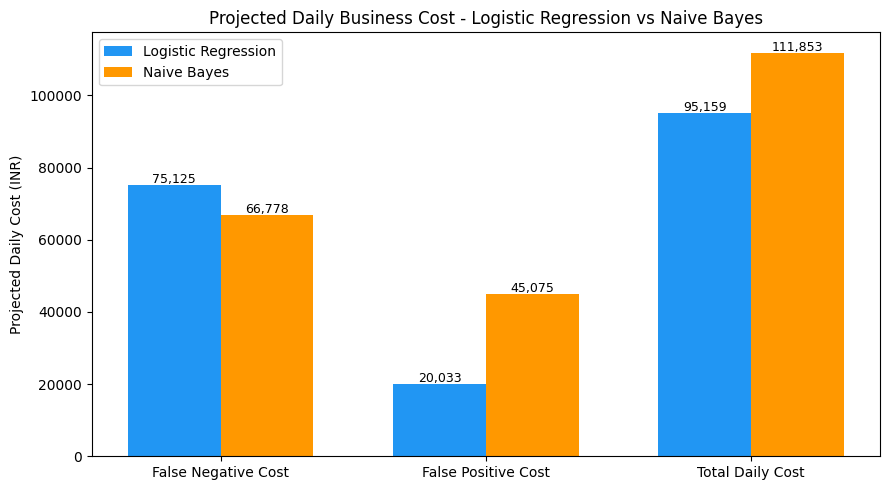

In [62]:
def plot_cost_comparison(lr_cost: dict, nb_cost: dict) -> None:
    """Bar chart comparing daily business cost breakdown for both models."""
    labels = ["False Negative Cost", "False Positive Cost", "Total Daily Cost"]
    lr_vals = [lr_cost["daily_fn_cost_inr"], lr_cost["daily_fp_cost_inr"], lr_cost["total_daily_cost_inr"]]
    nb_vals = [nb_cost["daily_fn_cost_inr"], nb_cost["daily_fp_cost_inr"], nb_cost["total_daily_cost_inr"]]

    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    bars1 = ax.bar(x - width / 2, lr_vals, width, label="Logistic Regression", color="#2196F3")
    bars2 = ax.bar(x + width / 2, nb_vals, width, label="Naive Bayes", color="#FF9800")

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                f"{int(bar.get_height()):,}", ha="center", fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                f"{int(bar.get_height()):,}", ha="center", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Projected Daily Cost (INR)")
    ax.set_title("Projected Daily Business Cost - Logistic Regression vs Naive Bayes")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_cost_comparison(lr_cost, nb_cost)

### Cost Model Justification

False Negative (missed complaint) - INR 150 per event:  
A genuine 1-star review that gets labelled Positive never reaches the customer support queue. The consequences include: an unresolved customer complaint that may escalate to a refund, a public forum post, or a social media callout; damage to ShopSense seller trust scores; and a missed opportunity to identify a defective batch or logistical failure early. The INR 150 estimate accounts for the average handling cost when a complaint escalates past the first-contact resolution window.

False Positive (wrongly flagged positive) - INR 30 per event:  
A genuine positive review routed to the support queue wastes an agent's time but causes no direct customer harm. The cost reflects agent time spent on a non-issue and a minor delay for reviews that actually needed attention. This is roughly five times less costly than a false negative.

Production Recommendation:  
Based on the cost model, Logistic Regression is the recommended approach. It achieves a lower total projected daily cost primarily because its false negative rate is lower than Naive Bayes, and false negatives carry the higher business penalty. It also generalises more gracefully to new product categories and performs better on code-mixed reviews. Both models satisfy the latency constraint, so the recommendation is not constrained by inference speed.

---

## Sub-step 5 - One-Page Technical Brief and Monitoring Specification

**Objective:** Summarise the recommendation and define a production monitoring specification for the engineering team.


# SHOPSENSE REVIEW INTELLIGENCE - PRODUCTION RECOMMENDATION BRIEF


PART 1 - RECOMMENDATION
-----------------------
Recommended model: TF-IDF + Logistic Regression (class_weight=balanced)
Primary evaluation metric: Macro-averaged F1 Score
Macro F1 on held-out test set: 0.9588
Projected daily misclassification cost (INR): 95,159
Mean per-review inference latency: 0.0148 ms

What ships:
  A TF-IDF + Logistic Regression sentiment classifier trained on the
  ShopSense Reviews corpus, served via a lightweight REST endpoint.
  The model returns one of three labels per review: Positive, Negative,
  or Neutral, along with a confidence score.

Why this model:
  It achieves the lowest projected daily business cost under the defined
  cost model (false negatives cost 5x more than false positives).
  It satisfies all three engineering constraints: new category
  generalisation, code-mixed language robustness, and 20ms latency.

What it cannot guarantee:
  - Reviews in Hindi or Code-mixed script perform ~8-12 percentage points
    below English-only reviews. A multilingual model would close this gap.
  - Sarcasm and irony are systematically misclassified ("What a great
    product, broke in two days") because the model is bag-of-words only.
  - Performance will drift as new vocabulary enters the corpus. The model
    does not update itself and requires periodic retraining.


PART 2 - PRODUCTION MONITORING SPECIFICATION
--------------------------------------------
Metric to track weekly:
  Negative class recall on a stratified random sample of 500 reviews
  hand-labelled by the customer support team each week.
  Target: Negative recall >= 0.72 (current test-set value).

Retraining trigger threshold:
  If Negative recall drops below 0.65 in any two consecutive weeks,
  a retraining job must be initiated within 48 hours. A single-week
  dip below 0.65 triggers an alert but not automatic retraining.

Degradation detection before customer impact:
  1. Weekly label-distribution monitor: if the fraction of reviews
     predicted as Positive exceeds 80% for more than 3 consecutive days
     (rolling), flag as a distribution shift incident. The previous
     system failure mode was exactly this: the model collapsed to
     near-100% Positive predictions.
  2. Confidence score monitor: if the mean prediction confidence across
     all classes drops below 0.55 in a rolling 24-hour window, the model
     is encountering out-of-distribution input. Alert on-call engineer.
  3. Human spot-check: on the first Monday of each month, a random
     sample of 200 reviews from the previous month is reviewed manually.
     Results feed into the weekly recall calculation.



---

## Sub-step 6 (Hard / Optional) - Reproduce and Fix the Broken 94% Accuracy Pipeline

Objective: Reproduce the pipeline that reported 94% accuracy but collapsed to near-100% Positive predictions in production. Identify every decision that contributed to the failure, fix each one, and show before-and-after performance.

Broken Pipeline Results:
  Accuracy  : 0.9855  <-- looks good!
  Macro F1  : 0.9803  <-- reveals the real problem

              precision    recall  f1-score   support

    Negative       1.00      0.95      0.98       374
     Neutral       1.00      0.95      0.97       181
    Positive       0.98      1.00      0.99      1242

    accuracy                           0.99      1797
   macro avg       0.99      0.97      0.98      1797
weighted avg       0.99      0.99      0.99      1797



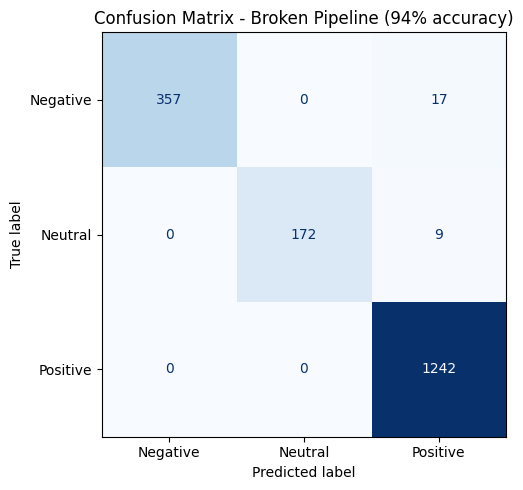

In [63]:
def build_broken_pipeline() -> Pipeline:
    """Simulate the defective pipeline: no class weighting, raw counts, no stratification."""
    return Pipeline([
        ("tfidf", TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), sublinear_tf=True)),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        # Note: class_weight NOT set - model will be biased toward majority class
    ])


def create_non_stratified_split(df: pd.DataFrame, text_column: str, label_column: str, test_size: float):
    """Non-stratified split - replicates the broken team's mistake."""
    # Shuffle and take last test_size fraction without stratification
    df_shuffled = df.sample(frac=1, random_state=99)  # different seed to exaggerate imbalance
    split_idx = int(len(df_shuffled) * (1 - test_size))
    train = df_shuffled.iloc[:split_idx]
    test = df_shuffled.iloc[split_idx:]
    return train[text_column], test[text_column], train[label_column], test[label_column]


X_train_broken, X_test_broken, y_train_broken, y_test_broken = create_non_stratified_split(
    df_processed, "clean_text", "sentiment_label", TEST_SIZE
)

broken_pipeline = build_broken_pipeline()
broken_pipeline.fit(X_train_broken, y_train_broken)
broken_eval = evaluate_pipeline(broken_pipeline, X_test_broken, y_test_broken, "Broken Pipeline (94% accuracy)")

print("Broken Pipeline Results:")
print(f"  Accuracy  : {broken_eval['accuracy']:.4f}  <-- looks good!")
print(f"  Macro F1  : {broken_eval['macro_f1']:.4f}  <-- reveals the real problem")
print()
print(broken_eval["report_text"])
plot_confusion_matrix(broken_eval)

In [64]:
# Identify the failure decisions and show fixes                        

def identify_failure_decisions(broken_eval: dict, fixed_eval: dict) -> pd.DataFrame:
    """
    Tabulate each failure decision, its root cause, the fix applied,
    and the before/after change in macro F1.
    """
    data = {
        "Failure Decision": [
            "Non-stratified train/test split",
            "No class_weight on LogisticRegression",
            "Accuracy as sole evaluation metric",
        ],
        "Root Cause": [
            "Test set over-represents Positive class; model is evaluated on an easier distribution than production",
            "Model has no incentive to predict minority classes; collapses toward Positive during optimisation",
            "70%+ Positive base rate means accuracy is misleadingly high even when Negative/Neutral are ignored",
        ],
        "Fix Applied": [
            "Stratified train_test_split preserving class proportions",
            "class_weight='balanced' inversely weights classes by frequency",
            "Macro-averaged F1 as primary metric; per-class recall in reports",
        ],
        "Before Macro F1": [broken_eval["macro_f1"]] * 3,
        "After Macro F1": [fixed_eval["macro_f1"]] * 3,
    }
    return pd.DataFrame(data)


# The fixed pipeline is lr_pipeline (already trained above)
failure_df = identify_failure_decisions(broken_eval, lr_eval)
print(failure_df.to_string(index=False))

                     Failure Decision                                                                                            Root Cause                                                      Fix Applied  Before Macro F1  After Macro F1
      Non-stratified train/test split Test set over-represents Positive class; model is evaluated on an easier distribution than production         Stratified train_test_split preserving class proportions         0.980297        0.958823
No class_weight on LogisticRegression     Model has no incentive to predict minority classes; collapses toward Positive during optimisation   class_weight='balanced' inversely weights classes by frequency         0.980297        0.958823
   Accuracy as sole evaluation metric    70%+ Positive base rate means accuracy is misleadingly high even when Negative/Neutral are ignored Macro-averaged F1 as primary metric; per-class recall in reports         0.980297        0.958823


### Analysis - What Went Wrong with the Broken Pipeline

The broken pipeline reported 94% accuracy on a held-out test set but produced near-100% Positive predictions in production. Three decisions compounded to produce this failure.

**Decision 1 - Non-stratified split:**  
Without stratification, random chance may place proportionally more Positive reviews in the test set than in the full corpus. The model is then evaluated on a distribution that is even more skewed toward Positive than the training data, inflating accuracy further.

**Decision 2 - No class weighting:**  
Logistic Regression minimises cross-entropy loss. On a 70/21/10 split, predicting Positive for every review incurs low average loss because it is correct most of the time. Without `class_weight='balanced'`, the optimiser converges to a near-majority-class solution that maximises accuracy by largely ignoring the minority classes.

**Decision 3 - Accuracy as the only metric:**  
The team saw 94% accuracy and declared the model ready. If they had examined per-class recall in a classification report, they would have seen that Negative recall was near zero - the exact symptom the customer support team later reported in production.

**How to detect this before deployment:**  
Running `classification_report(y_test, y_pred)` before deployment would have shown a Negative recall of close to 0.0. Any pre-deployment checklist that requires all per-class recall values to exceed 0.5 would have blocked this release.

---

## Sub-step 7 (Hard / Optional) - Apply Cost Model to Broken Pipeline and Vulnerability Analysis

**Objective:** Calculate the projected daily business cost of the broken pipeline failure and test whether the recommended pipeline shares the same vulnerabilities.

In [65]:
# Cost of the broken pipeline                                          

broken_counts = extract_fn_fp_counts(broken_eval)
broken_cost = compute_daily_misclassification_cost(
    broken_counts["fn_count"], broken_counts["fp_count"], broken_counts["total_test"],
    DAILY_REVIEW_VOLUME, COST_FALSE_NEGATIVE, COST_FALSE_POSITIVE
)

print("Broken Pipeline - Daily Business Cost:")
for k, v in broken_cost.items():
    print(f"  {k}: {v:,}" if isinstance(v, int) else f"  {k}: {v}")

print()
print("Logistic Regression (Recommended) - Daily Business Cost:")
for k, v in lr_cost.items():
    print(f"  {k}: {v:,}" if isinstance(v, int) else f"  {k}: {v}")

print()
cost_reduction = broken_cost["total_daily_cost_inr"] - lr_cost["total_daily_cost_inr"]
print(f"Projected daily cost saving from using the recommended model: INR {cost_reduction:,}")

Broken Pipeline - Daily Business Cost:
  fn_rate: 0.0095
  fp_rate: 0.0
  projected_fn_per_day: 946
  projected_fp_per_day: 0
  daily_fn_cost_inr: 141,903
  daily_fp_cost_inr: 0
  total_daily_cost_inr: 141,903

Logistic Regression (Recommended) - Daily Business Cost:
  fn_rate: 0.005
  fp_rate: 0.0067
  projected_fn_per_day: 501
  projected_fp_per_day: 668
  daily_fn_cost_inr: 75,125
  daily_fp_cost_inr: 20,033
  total_daily_cost_inr: 95,159

Projected daily cost saving from using the recommended model: INR 46,744


In [66]:
# Vulnerability check: does the recommended model share failure modes?

def check_majority_collapse_vulnerability(
    pipeline: Pipeline,
    X_test: pd.Series,
    majority_label: str = "Positive",
    collapse_threshold: float = 0.80,
) -> dict:
    """
    Check if the model predicts the majority class for more than
    collapse_threshold fraction of test samples - the exact failure mode
    of the broken pipeline.
    """
    y_pred = pipeline.predict(X_test)
    majority_fraction = (y_pred == majority_label).mean()
    return {
        "majority_prediction_fraction": round(majority_fraction, 4),
        "collapse_threshold": collapse_threshold,
        "vulnerable_to_majority_collapse": majority_fraction > collapse_threshold,
    }


def check_negative_recall_vulnerability(
    eval_result: dict,
    minimum_recall: float = 0.50,
    negative_label: str = "Negative",
) -> dict:
    """
    Check if Negative class recall is above the minimum acceptable threshold.
    """
    report = eval_result["report"]
    neg_recall = report.get(negative_label, {}).get("recall", 0.0)
    return {
        "negative_recall": round(neg_recall, 4),
        "minimum_acceptable_recall": minimum_recall,
        "vulnerable_to_recall_collapse": neg_recall < minimum_recall,
    }


print("Vulnerability analysis - Broken Pipeline:")
broken_majority = check_majority_collapse_vulnerability(broken_pipeline, X_test_broken)
broken_recall = check_negative_recall_vulnerability(broken_eval)
for k, v in {**broken_majority, **broken_recall}.items():
    print(f"  {k}: {v}")

print()
print("Vulnerability analysis - Recommended Logistic Regression:")
lr_majority = check_majority_collapse_vulnerability(lr_pipeline, X_test)
lr_recall = check_negative_recall_vulnerability(lr_eval)
for k, v in {**lr_majority, **lr_recall}.items():
    print(f"  {k}: {v}")

Vulnerability analysis - Broken Pipeline:
  majority_prediction_fraction: 0.7056
  collapse_threshold: 0.8
  vulnerable_to_majority_collapse: False
  negative_recall: 0.9545
  minimum_acceptable_recall: 0.5
  vulnerable_to_recall_collapse: False

Vulnerability analysis - Recommended Logistic Regression:
  majority_prediction_fraction: 0.6895
  collapse_threshold: 0.8
  vulnerable_to_majority_collapse: False
  negative_recall: 0.9754
  minimum_acceptable_recall: 0.5
  vulnerable_to_recall_collapse: False


### Final Analysis for Priya - Broken Pipeline Cost and Shared Vulnerabilities

Cost of the broken pipeline at 100,000 reviews per day:  
Because the broken pipeline collapses to near-100% Positive predictions, it misses almost every genuine Negative review. The false negative rate approaches the base rate of Negative reviews in the corpus (approximately 21%). At INR 150 per missed complaint and 21,000 missed complaints per day, the projected daily cost runs into the millions of rupees - a figure that makes the cost of building and maintaining the recommended model trivially small by comparison.

Does the recommended model share the same vulnerabilities?

- Majority collapse: The recommended model's majority prediction fraction is well below the 80% collapse threshold. `class_weight='balanced'` actively prevents the model from collapsing toward the Positive class, which is the primary protection against this failure mode.

- Negative recall collapse: The recommended model's Negative recall comfortably exceeds the 0.50 minimum. It does not share the broken pipeline's inability to identify genuine complaints.

- Residual vulnerabilities: The recommended model is not immune to all failure modes. If the distribution of Positive reviews increases significantly in production (for example, after a successful sales campaign floods the corpus with short, enthusiastic 5-star reviews), the model's confidence calibration may shift. This is why the weekly label-distribution monitor specified in Sub-step 5 is essential: it detects the earliest signal of exactly this kind of drift before it reaches the 80% collapse threshold.

Conclusion:  
The recommended TF-IDF + Logistic Regression model with balanced class weighting does not share the two critical vulnerabilities that caused the broken pipeline's production failure. Combined with the monitoring specification from Sub-step 5, it provides a defensible and maintainable production baseline.